In [1]:
import os

BASE_PATH = "/content/drive/MyDrive/gnn_bert_music_project"

DATA_PATH = os.path.join(BASE_PATH,"datasets")

FMA_PATH = os.path.join(DATA_PATH,"fma_medium")

METADATA_PATH = os.path.join(DATA_PATH,"fma_metadata")

MUSICCAPS_PATH = os.path.join(DATA_PATH,"musiccaps")


print("BASE:", BASE_PATH)
print("FMA:", FMA_PATH)
print("METADATA:", METADATA_PATH)
print("MUSICCAPS:", MUSICCAPS_PATH)

BASE: /content/drive/MyDrive/gnn_bert_music_project
FMA: /content/drive/MyDrive/gnn_bert_music_project/datasets/fma_medium
METADATA: /content/drive/MyDrive/gnn_bert_music_project/datasets/fma_metadata
MUSICCAPS: /content/drive/MyDrive/gnn_bert_music_project/datasets/musiccaps


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
MUSICCAPS_PATH = "/content/drive/MyDrive/gnn_bert_music_project/musiccaps"

In [4]:
import os

print(os.listdir(MUSICCAPS_PATH))

['musiccaps.csv']


In [5]:
import pandas as pd

musiccaps = pd.read_csv(
    MUSICCAPS_PATH + "/musiccaps.csv"
)

musiccaps.head()

,ytid,start_s,end_s,audioset_positive_labels,aspect_list,caption,author_id,is_balanced_subset,is_audioset_eval
0,-0Gj8-vB1q4,30,40,"/m/0140xf,/m/02cjck,/m/04rlf","['low quality', 'sustained strings melody', 's...",The low quality recording features a ballad so...,4,False,True
1,-0SdAVK79lg,30,40,"/m/0155w,/m/01lyv,/m/0342h,/m/042v_gx,/m/04rlf...","['guitar song', 'piano backing', 'simple percu...",This song features an electric guitar as the m...,0,False,False
2,-0vPFx-wRRI,30,40,"/m/025_jnm,/m/04rlf","['amateur recording', 'finger snipping', 'male...",a male voice is singing a melody with changing...,6,False,True
3,-0xzrMun0Rs,30,40,"/m/01g90h,/m/04rlf","['backing track', 'jazzy', 'digital drums', 'p...",This song contains digital drums playing a sim...,6,False,True
4,-1LrH01Ei1w,30,40,"/m/02p0sh1,/m/04rlf","['rubab instrument', 'repetitive melody on dif...",This song features a rubber instrument being p...,0,False,False


In [6]:
musiccaps.columns

Index(['ytid', 'start_s', 'end_s', 'audioset_positive_labels', 'aspect_list',
       'caption', 'author_id', 'is_balanced_subset', 'is_audioset_eval'],
      dtype='object')

In [7]:
music_text = musiccaps[['caption']].dropna()

music_text.head()

,caption
0,The low quality recording features a ballad so...
1,This song features an electric guitar as the m...
2,a male voice is singing a melody with changing...
3,This song contains digital drums playing a sim...
4,This song features a rubber instrument being p...


In [8]:
musiccaps[['caption','aspect_list']].head()

,caption,aspect_list
0,The low quality recording features a ballad so...,"['low quality', 'sustained strings melody', 's..."
1,This song features an electric guitar as the m...,"['guitar song', 'piano backing', 'simple percu..."
2,a male voice is singing a melody with changing...,"['amateur recording', 'finger snipping', 'male..."
3,This song contains digital drums playing a sim...,"['backing track', 'jazzy', 'digital drums', 'p..."
4,This song features a rubber instrument being p...,"['rubab instrument', 'repetitive melody on dif..."


In [9]:
!pip install transformers datasets accelerate -q

In [10]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [11]:
sample = musiccaps.iloc[0]['caption']

tokens = tokenizer(
    sample,
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

tokens

{'input_ids': tensor([[  101,  1996,  2659,  3737,  3405,  2838,  1037, 11571,  2299,  2008,
          3397,  8760,  7817,  1010, 11463,  8261,  3682,  8531,  1998,  3730,
          2931,  5554,  4823,  2058,  2009,  1012,  2009,  4165,  6517,  1998,
          3969,  3993,  1010,  2066,  2242,  2017,  2052,  2963,  2012,  4465,
          2578,  1012,   102,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,  

In [12]:
import torch
from torch.utils.data import Dataset


class MusicCapsDataset(Dataset):

    def __init__(self, dataframe):

        self.texts = dataframe["caption"].values


    def __len__(self):

        return len(self.texts)


    def __getitem__(self, idx):

        text = self.texts[idx]


        encoding = tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )


        return {
            "input_ids":
            encoding["input_ids"].squeeze(0),

            "attention_mask":
            encoding["attention_mask"].squeeze(0)
        }

In [13]:
dataset = MusicCapsDataset(music_text)

len(dataset)

5521

In [14]:
sample = dataset[0]

sample

{'input_ids': tensor([  101,  1996,  2659,  3737,  3405,  2838,  1037, 11571,  2299,  2008,
          3397,  8760,  7817,  1010, 11463,  8261,  3682,  8531,  1998,  3730,
          2931,  5554,  4823,  2058,  2009,  1012,  2009,  4165,  6517,  1998,
          3969,  3993,  1010,  2066,  2242,  2017,  2052,  2963,  2012,  4465,
          2578,  1012,   102,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [15]:
len(dataset)

5521

In [16]:
dataset[0]

{'input_ids': tensor([  101,  1996,  2659,  3737,  3405,  2838,  1037, 11571,  2299,  2008,
          3397,  8760,  7817,  1010, 11463,  8261,  3682,  8531,  1998,  3730,
          2931,  5554,  4823,  2058,  2009,  1012,  2009,  4165,  6517,  1998,
          3969,  3993,  1010,  2066,  2242,  2017,  2052,  2963,  2012,  4465,
          2578,  1012,   102,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [17]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

batch = next(iter(train_loader))

batch

{'input_ids': tensor([[ 101, 2023, 6150,  ...,    0,    0,    0],
         [ 101, 1996, 2659,  ...,    0,    0,    0],
         [ 101, 1996, 2659,  ...,    0,    0,    0],
         ...,
         [ 101, 2023, 5746,  ...,    0,    0,    0],
         [ 101, 8401, 1010,  ...,    0,    0,    0],
         [ 101, 1037, 2177,  ...,    0,    0,    0]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]])}

In [18]:
from transformers import BertModel

bert_model = BertModel.from_pretrained(
    "bert-base-uncased"
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [19]:
output = bert_model(
    input_ids=batch["input_ids"],
    attention_mask=batch["attention_mask"]
)

output.last_hidden_state.shape

torch.Size([16, 128, 768])

In [20]:
cls_embedding = output.last_hidden_state[:,0,:]

cls_embedding.shape

torch.Size([16, 768])

In [21]:
import torch.nn as nn


class BERTMusicClassifier(nn.Module):

    def __init__(self, num_labels):

        super().__init__()

        self.bert = BertModel.from_pretrained(
            "bert-base-uncased"
        )

        self.dropout = nn.Dropout(0.3)

        self.classifier = nn.Linear(
            768,
            num_labels
        )


    def forward(
        self,
        input_ids,
        attention_mask
    ):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )


        cls = outputs.last_hidden_state[:,0,:]


        cls = self.dropout(cls)


        logits = self.classifier(cls)

        return logits

In [22]:
musiccaps["aspect_list"].head()

,aspect_list
0,"['low quality', 'sustained strings melody', 's..."
1,"['guitar song', 'piano backing', 'simple percu..."
2,"['amateur recording', 'finger snipping', 'male..."
3,"['backing track', 'jazzy', 'digital drums', 'p..."
4,"['rubab instrument', 'repetitive melody on dif..."


In [23]:
musiccaps["aspect_list"].iloc[0]

"['low quality', 'sustained strings melody', 'soft female vocal', 'mellow piano melody', 'sad', 'soulful', 'ballad']"

In [24]:
type(musiccaps["aspect_list"].iloc[0])

str

In [25]:
['guitar','piano']

['guitar', 'piano']

In [26]:
import ast

musiccaps["aspect_list"] = musiccaps["aspect_list"].apply(
    ast.literal_eval
)

musiccaps["aspect_list"].iloc[0]

['low quality',
 'sustained strings melody',
 'soft female vocal',
 'mellow piano melody',
 'sad',
 'soulful',
 'ballad']

In [27]:
from collections import Counter


all_tags = []

for tags in musiccaps["aspect_list"]:
    all_tags.extend(tags)


tag_counts = Counter(all_tags)


top_tags = [
    tag for tag, count in tag_counts.most_common(50)
]


top_tags[:20]

['low quality',
 'instrumental',
 'emotional',
 'noisy',
 'passionate',
 'medium tempo',
 'energetic',
 'amateur recording',
 'live performance',
 'slow tempo',
 'acoustic drums',
 'fast tempo',
 'mono',
 'groovy',
 'bass guitar',
 'electric guitar',
 'acoustic guitar',
 'instrumental music',
 'uptempo',
 'piano']

In [28]:
import torch


def create_label_vector(tags):

    vector = []

    for tag in top_tags:

        if tag in tags:
            vector.append(1)
        else:
            vector.append(0)

    return torch.tensor(
        vector,
        dtype=torch.float
    )


musiccaps["labels"] = musiccaps["aspect_list"].apply(
    create_label_vector
)

In [29]:
musiccaps["labels"].iloc[0]

tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [30]:
len(top_tags)

50

In [31]:
class MusicCapsDataset(Dataset):

    def __init__(self, dataframe):

        self.texts = dataframe["caption"].values
        self.labels = dataframe["labels"].values


    def __len__(self):

        return len(self.texts)


    def __getitem__(self, idx):

        text = self.texts[idx]

        encoding = tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )


        return {

            "input_ids":
            encoding["input_ids"].squeeze(0),

            "attention_mask":
            encoding["attention_mask"].squeeze(0),

            "labels":
            self.labels[idx]

        }

In [32]:
dataset = MusicCapsDataset(musiccaps)

sample = dataset[0]

sample

{'input_ids': tensor([  101,  1996,  2659,  3737,  3405,  2838,  1037, 11571,  2299,  2008,
          3397,  8760,  7817,  1010, 11463,  8261,  3682,  8531,  1998,  3730,
          2931,  5554,  4823,  2058,  2009,  1012,  2009,  4165,  6517,  1998,
          3969,  3993,  1010,  2066,  2242,  2017,  2052,  2963,  2012,  4465,
          2578,  1012,   102,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [33]:
from torch.utils.data import random_split


train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size


train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)


print(len(train_dataset))
print(len(val_dataset))

4416
1105


In [34]:
from torch.utils.data import DataLoader


train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

In [35]:
batch = next(iter(train_loader))

batch["input_ids"].shape

torch.Size([8, 128])

In [36]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


model = BERTMusicClassifier(
    num_labels=50
)


model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTMusicClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

In [37]:
device

device(type='cpu')

In [38]:
import torch.nn as nn


criterion = nn.BCEWithLogitsLoss()

In [39]:
from torch.optim import AdamW


optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

In [40]:
def train_epoch(model, loader):

    model.train()

    total_loss = 0


    for batch in loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)


        optimizer.zero_grad()


        outputs = model(
            input_ids,
            attention_mask
        )


        loss = criterion(
            outputs,
            labels
        )


        loss.backward()

        optimizer.step()


        total_loss += loss.item()


    return total_loss / len(loader)

In [41]:
def evaluate(model, loader):

    model.eval()

    total_loss = 0


    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)


            outputs = model(
                input_ids,
                attention_mask
            )


            loss = criterion(
                outputs,
                labels
            )


            total_loss += loss.item()


    return total_loss / len(loader)

In [42]:
epochs = 3


for epoch in range(epochs):

    train_loss = train_epoch(
        model,
        train_loader
    )


    val_loss = evaluate(
        model,
        val_loader
    )


    print(
        f"Epoch {epoch+1}"
    )

    print(
        "Train loss:",
        train_loss
    )

    print(
        "Val loss:",
        val_loss
    )

KeyboardInterrupt: 

In [43]:
import os

print(os.listdir(
    "/content/drive/MyDrive/gnn_bert_music_project"
))

['datasets', 'musiccaps', 'processed', 'models', 'results']


In [44]:
print(os.listdir(
    "/content/drive/MyDrive/gnn_bert_music_project/datasets"
))

['fma', 'musiccaps']


In [45]:
FMA_PATH = "/content/drive/MyDrive/gnn_bert_music_project/datasets/fma"

import os

print(os.listdir(FMA_PATH)[:20])

['fma_metadata.zip', 'fma_medium.zip', 'fma_medium', 'fma_metadata']


In [46]:
FMA_AUDIO_PATH = "/content/drive/MyDrive/gnn_bert_music_project/datasets/fma/fma_medium"

FMA_META_PATH = "/content/drive/MyDrive/gnn_bert_music_project/datasets/fma/fma_metadata"

In [47]:
import os

print(os.listdir(FMA_META_PATH))

['fma_metadata']


In [48]:
FMA_META_PATH = "/content/drive/MyDrive/gnn_bert_music_project/datasets/fma/fma_metadata/fma_metadata"

import os

print(os.listdir(FMA_META_PATH))

['README.txt', 'checksums', 'not_found.pickle', 'raw_genres.csv', 'raw_albums.csv', 'raw_artists.csv', 'raw_tracks.csv', 'tracks.csv', 'genres.csv', 'raw_echonest.csv', 'echonest.csv', 'features.csv']


In [49]:
import pandas as pd

tracks = pd.read_csv(
    FMA_META_PATH + "/tracks.csv",
    header=[0,1],
    index_col=0
)

tracks.head()

album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
3               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
10              0  2008-11-26 01:45:08  2008-02-06 00:00:00      NaN   
20              0  2008-11-26 01:45:05  2009-01-06 00:00:00      NaN   

                                                                          \
         favorites id                                information listens   
track_id                                                                   
2                4  1                                    <p></p>    6073   
3                4  1                                    <p></p>    6073   
5                4  1                                    <p></p>    6073   
10               4  6                                        NaN   47632   
20               2  4  <p> "spiritual songs" from Nicky Cook</p>    2710   

                        ...       track                         \
         producer tags  ... information interest language_code   
track_id                ...                                      
2             NaN   []  ...         NaN     4656            en   
3             NaN   []  ...         NaN     1470            en   
5             NaN   []  ...         NaN     1933            en   
10            NaN   []  ...         NaN    54881            en   
20            NaN   []  ...         NaN      978            en   

                                                                              \
                                                    license listens lyricist   
track_id                                                                       
2         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1293      NaN   
3         Attribution-NonCommercial-ShareAlike 3.0 Inter...     514      NaN   
5         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1151      NaN   
10        Attribution-NonCommercial-NoDerivatives (aka M...   50135      NaN   
20        Attribution-NonCommercial-NoDerivatives (aka M...     361      NaN   

                                                 
         number publisher tags            title  
track_id                                         
2             3       NaN   []             Food  
3             4       NaN   []     Electric Ave  
5             6       NaN   []       This World  
10            1       NaN   []          Freeway  
20            3       NaN   []  Spiritual Level  

[5 rows x 52 columns]

In [50]:
tracks["track"]["genre_top"].value_counts().head(10)

,count
genre_top,
Rock,14182
Experimental,10608
Electronic,9372
Hip-Hop,3552
Folk,2803
Pop,2332
Instrumental,2079
International,1389
Classical,1230


In [51]:
FMA_AUDIO_PATH = "/content/drive/MyDrive/gnn_bert_music_project/datasets/fma/fma_medium"

import os

print(os.listdir(FMA_AUDIO_PATH)[:10])

['fma_medium']


In [52]:
FMA_AUDIO_PATH = "/content/drive/MyDrive/gnn_bert_music_project/datasets/fma/fma_medium"

In [53]:
import os

print(os.listdir(FMA_AUDIO_PATH)[:10])

['fma_medium']


In [55]:
FMA_AUDIO_PATH = "/content/drive/MyDrive/gnn_bert_music_project/datasets/fma/fma_medium/fma_medium"

import os

print(FMA_AUDIO_PATH)

print(os.listdir(FMA_AUDIO_PATH)[:10])

/content/drive/MyDrive/gnn_bert_music_project/datasets/fma/fma_medium/fma_medium
['098', '005', '000', 'README.txt', 'checksums', '001', '002', '003', '004', '006']


In [56]:
for root, dirs, files in os.walk(FMA_AUDIO_PATH):
    mp3_files = [f for f in files if f.endswith(".mp3")]

    if mp3_files:
        print("Folder:", root)
        print("File:", mp3_files[0])
        break

Folder: /content/drive/MyDrive/gnn_bert_music_project/datasets/fma/fma_medium/fma_medium/098
File: 098909.mp3


In [57]:
import os

print(os.listdir(FMA_AUDIO_PATH)[:10])

['098', '005', '000', 'README.txt', 'checksums', '001', '002', '003', '004', '006']


In [58]:
audio_file = "/content/drive/MyDrive/gnn_bert_music_project/datasets/fma/fma_medium/fma_medium/098/098909.mp3"

import librosa

audio, sr = librosa.load(
    audio_file,
    sr=22050
)

print(audio.shape)
print(sr)

(660984,)
22050


In [59]:
import numpy as np
import librosa


def extract_segment_features(audio, sr, segment_seconds=5):

    segment_length = int(sr * segment_seconds)

    features = []


    for start in range(
        0,
        len(audio),
        segment_length
    ):

        segment = audio[start:start+segment_length]


        if len(segment) < segment_length:
            continue


        # Chroma (12)
        chroma = librosa.feature.chroma_stft(
            y=segment,
            sr=sr
        )


        # MFCC (13)
        mfcc = librosa.feature.mfcc(
            y=segment,
            sr=sr,
            n_mfcc=13
        )


        feature = np.concatenate(
            [
                np.mean(chroma, axis=1),
                np.mean(mfcc, axis=1)
            ]
        )


        features.append(feature)


    return np.array(features)

In [60]:
node_features = extract_segment_features(
    audio,
    sr
)


print(node_features.shape)

(5, 25)


In [61]:
import torch


def create_graph(features):

    num_nodes = len(features)

    edges = []


    for i in range(num_nodes-1):

        edges.append([i, i+1])
        edges.append([i+1, i])


    edge_index = torch.tensor(
        edges,
        dtype=torch.long
    ).t()


    x = torch.tensor(
        features,
        dtype=torch.float
    )


    return x, edge_index

In [62]:
genres = tracks["track"]["genre_top"].dropna().unique()

genre_to_id = {
    genre:i
    for i,genre in enumerate(genres)
}

print(genre_to_id)

In [63]:
x, edge_index = create_graph(node_features)

print("Node features shape:", x.shape)
print("Edge index shape:", edge_index.shape)
print("\nEdge index:")
print(edge_index)

Node features shape: torch.Size([5, 25])
Edge index shape: torch.Size([2, 8])

Edge index:
tensor([[0, 1, 1, 2, 2, 3, 3, 4],
        [1, 0, 2, 1, 3, 2, 4, 3]])


In [64]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.3 MB/s eta 0:00:00


In [65]:
from torch_geometric.data import Data

graph = Data(
    x=x,
    edge_index=edge_index
)

print(graph)
print("Number of nodes:", graph.num_nodes)
print("Number of edges:", graph.num_edges)
print("Features per node:", graph.num_node_features)

Data(x=[5, 25], edge_index=[2, 8])
Number of nodes: 5
Number of edges: 8
Features per node: 25


In [66]:
track_id = 98909

In [67]:
track_id = 98909

print(
    tracks.loc[
        track_id,
        ("track", "genre_top")
    ]
)

Electronic


In [68]:
genre = tracks.loc[
    track_id,
    ("track", "genre_top")
]

print("Track:", track_id)
print("Genre:", genre)

Track: 98909
Genre: Electronic


In [72]:
genres = tracks["track"]["genre_top"].dropna().unique()

genre_to_id = {
    genre:i
    for i,genre in enumerate(genres)
}

print(genre_to_id)

{'Hip-Hop': 0, 'Pop': 1, 'Rock': 2, 'Experimental': 3, 'Folk': 4, 'Jazz': 5, 'Electronic': 6, 'Spoken': 7, 'International': 8, 'Soul-RnB': 9, 'Blues': 10, 'Country': 11, 'Classical': 12, 'Old-Time / Historic': 13, 'Instrumental': 14, 'Easy Listening': 15}


In [73]:
graph.y = torch.tensor(
    [genre_to_id[genre]],
    dtype=torch.long
)

print(graph)
print(graph.y)

Data(x=[5, 25], edge_index=[2, 8], y=[1])
tensor([6])


In [74]:
import torch.nn as nn
from torch_geometric.nn import SAGEConv, global_mean_pool


class MusicGraphSAGE(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_classes):

        super().__init__()

        self.conv1 = SAGEConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = SAGEConv(
            hidden_dim,
            hidden_dim
        )


        self.classifier = nn.Linear(
            hidden_dim,
            num_classes
        )


    def forward(self, x, edge_index, batch):

        x = self.conv1(
            x,
            edge_index
        )

        x = torch.relu(x)


        x = self.conv2(
            x,
            edge_index
        )

        x = torch.relu(x)


        x = global_mean_pool(
            x,
            batch
        )


        return self.classifier(x)

In [75]:
from torch_geometric.loader import DataLoader


graph.batch = torch.zeros(
    graph.num_nodes,
    dtype=torch.long
)


model = MusicGraphSAGE(
    input_dim=25,
    hidden_dim=64,
    num_classes=len(genre_to_id)
)


output = model(
    graph.x,
    graph.edge_index,
    graph.batch
)


print(output.shape)

torch.Size([1, 16])


In [76]:
import torch
import torch.nn as nn

from torch_geometric.nn import (
    SAGEConv,
    global_mean_pool
)

In [77]:
class MusicGraphSAGE(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        num_classes
    ):

        super().__init__()


        self.conv1 = SAGEConv(
            input_dim,
            hidden_dim
        )


        self.conv2 = SAGEConv(
            hidden_dim,
            hidden_dim
        )


        self.classifier = nn.Linear(
            hidden_dim,
            num_classes
        )


    def forward(
        self,
        x,
        edge_index,
        batch
    ):

        x = self.conv1(
            x,
            edge_index
        )

        x = torch.relu(x)


        x = self.conv2(
            x,
            edge_index
        )

        x = torch.relu(x)


        # graph-level representation
        x = global_mean_pool(
            x,
            batch
        )


        out = self.classifier(x)


        return out

In [78]:
graph.batch = torch.zeros(
    graph.num_nodes,
    dtype=torch.long
)

In [79]:
num_classes = len(genre_to_id)

print(num_classes)

16


In [80]:
gnn_model = MusicGraphSAGE(
    input_dim=25,
    hidden_dim=64,
    num_classes=num_classes
)

In [81]:
prediction = gnn_model(
    graph.x,
    graph.edge_index,
    graph.batch
)


print(prediction.shape)

torch.Size([1, 16])


In [82]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    gnn_model.parameters(),
    lr=0.001
)

In [83]:
for epoch in range(20):

    optimizer.zero_grad()


    output = gnn_model(
        graph.x,
        graph.edge_index,
        graph.batch
    )


    loss = criterion(
        output,
        graph.y
    )


    loss.backward()

    optimizer.step()


    print(
        epoch,
        loss.item()
    )

0 10.770259857177734
1 6.226205348968506
2 2.2104291915893555
3 0.13649575412273407
4 0.004907349124550819
5 0.0003010773507412523
6 2.7894584491150454e-05
7 3.4570634852570947e-06
8 5.960462772236497e-07
9 1.1920928244535389e-07
10 0.0
11 0.0
12 0.0
13 0.0
14 0.0
15 0.0
16 0.0
17 0.0
18 0.0
19 0.0


In [84]:
print(prediction.shape)

torch.Size([1, 16])


In [85]:
genres = tracks["track"]["genre_top"].dropna().unique()

genre_to_id = {
    g:i for i,g in enumerate(genres)
}

id_to_genre = {
    i:g for g,i in genre_to_id.items()
}

print(genre_to_id)

{'Hip-Hop': 0, 'Pop': 1, 'Rock': 2, 'Experimental': 3, 'Folk': 4, 'Jazz': 5, 'Electronic': 6, 'Spoken': 7, 'International': 8, 'Soul-RnB': 9, 'Blues': 10, 'Country': 11, 'Classical': 12, 'Old-Time / Historic': 13, 'Instrumental': 14, 'Easy Listening': 15}


In [86]:
import os
import torch
import librosa
import numpy as np

from torch_geometric.data import Data



def audio_to_graph(audio_path, label):

    audio, sr = librosa.load(
        audio_path,
        sr=22050
    )


    features=[]

    segment_length = sr*5


    for start in range(
        0,
        len(audio),
        segment_length
    ):

        segment = audio[
            start:start+segment_length
        ]


        if len(segment)<segment_length:
            continue


        chroma = librosa.feature.chroma_stft(
            y=segment,
            sr=sr
        )


        mfcc = librosa.feature.mfcc(
            y=segment,
            sr=sr,
            n_mfcc=13
        )


        feature=np.concatenate(
            [
                np.mean(chroma,axis=1),
                np.mean(mfcc,axis=1)
            ]
        )


        features.append(feature)



    x=torch.tensor(
        np.array(features),
        dtype=torch.float
    )


    edges=[]

    for i in range(len(features)-1):

        edges.append([i,i+1])
        edges.append([i+1,i])


    edge_index=torch.tensor(
        edges,
        dtype=torch.long
    ).t()


    y=torch.tensor(
        [label],
        dtype=torch.long
    )


    return Data(
        x=x,
        edge_index=edge_index,
        y=y
    )

In [87]:
test_graph = audio_to_graph(
    audio_file,
    genre_to_id["Electronic"]
)


print(test_graph)

Data(x=[5, 25], edge_index=[2, 8], y=[1])


In [88]:
print(test_graph)

Data(x=[5, 25], edge_index=[2, 8], y=[1])


In [89]:
import os

GRAPH_PATH = "/content/drive/MyDrive/gnn_bert_music_project/processed/graphs"

os.makedirs(
    GRAPH_PATH,
    exist_ok=True
)

print(GRAPH_PATH)

/content/drive/MyDrive/gnn_bert_music_project/processed/graphs


In [90]:
def get_audio_path(track_id):

    folder = str(track_id).zfill(6)[:3]

    filename = str(track_id).zfill(6) + ".mp3"

    path = os.path.join(
        FMA_AUDIO_PATH,
        folder,
        filename
    )

    return path

In [91]:
print(get_audio_path(98909))

/content/drive/MyDrive/gnn_bert_music_project/datasets/fma/fma_medium/fma_medium/098/098909.mp3


In [92]:
import tqdm


count = 0
failed = 0


for track_id in tracks.index:


    # skip tracks without genre
    try:
        genre = tracks.loc[
            track_id,
            ("track","genre_top")
        ]

    except:
        continue


    if pd.isna(genre):
        continue


    if genre not in genre_to_id:
        continue


    audio_path = get_audio_path(track_id)


    if not os.path.exists(audio_path):
        failed += 1
        continue


    try:

        graph = audio_to_graph(
            audio_path,
            genre_to_id[genre]
        )


        torch.save(
            graph,
            f"{GRAPH_PATH}/{track_id}.pt"
        )


        count += 1


    except Exception as e:
        failed += 1


    if count >= 1000:
        break


print("Created graphs:", count)
print("Failed:", failed)

/tmp/ipykernel_2825/553949997.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_2825/553949997.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Created graphs: 1000
Failed: 1880


In [93]:
import os

print(
    len(os.listdir(GRAPH_PATH))
)

print(
    os.listdir(GRAPH_PATH)[:5]
)

1002
['111226.pt', 'audio_graph.pt', '2.pt', '3.pt', '5.pt']


In [94]:
from torch_geometric.data import Dataset, Data


class MusicGraphDataset(Dataset):

    def __init__(self, root):

        self.files = [
            os.path.join(root,f)
            for f in os.listdir(root)
            if f.endswith(".pt")
        ]


    def len(self):

        return len(self.files)


    def get(self, idx):

        return torch.load(
            self.files[idx],
            weights_only=False
        )

In [96]:
from torch_geometric.data import Dataset
import os
import torch


class MusicGraphDataset(Dataset):

    def __init__(self, root):

        self.root = root

        self.files = [
            os.path.join(root, f)
            for f in os.listdir(root)
            if f.endswith(".pt")
        ]

        super().__init__(root)


    def len(self):

        return len(self.files)


    def get(self, idx):

        graph = torch.load(
            self.files[idx],
            weights_only=False
        )

        return graph

In [97]:
dataset = MusicGraphDataset(
    GRAPH_PATH
)

In [98]:
print("Total graphs:", len(dataset))

print(dataset[0])

Total graphs: 1002
Data(x=[3, 180], edge_index=[2, 2])


In [99]:
print(dataset[0])

Data(x=[3, 180], edge_index=[2, 2])


In [100]:
from collections import Counter

dims=[]

for i in range(len(dataset)):

    dims.append(
        dataset[i].x.shape[1]
    )


print(Counter(dims))

Counter({25: 1000, 180: 2})


In [101]:
valid_indices = []

for i in range(len(dataset)):

    if dataset[i].x.shape[1] == 25:
        valid_indices.append(i)


print("Valid graphs:", len(valid_indices))

Valid graphs: 1000


In [102]:
from torch.utils.data import Subset

clean_dataset = Subset(
    dataset,
    valid_indices
)

print(len(clean_dataset))

1000


In [103]:
from collections import Counter

labels=[]

for g in clean_dataset:
    labels.append(
        g.y.item()
    )


print(Counter(labels))

Counter({2: 458, 4: 122, 6: 89, 8: 78, 3: 54, 9: 42, 5: 36, 0: 34, 13: 25, 1: 23, 11: 21, 10: 13, 7: 3, 12: 2})


In [104]:
from torch.utils.data import random_split


train_size = int(
    0.8 * len(clean_dataset)
)

test_size = len(clean_dataset)-train_size


train_dataset, test_dataset = random_split(
    clean_dataset,
    [
        train_size,
        test_size
    ]
)


print(
    len(train_dataset),
    len(test_dataset)
)

800 200


In [105]:
print(Counter(labels))

Counter({2: 458, 4: 122, 6: 89, 8: 78, 3: 54, 9: 42, 5: 36, 0: 34, 13: 25, 1: 23, 11: 21, 10: 13, 7: 3, 12: 2})


In [106]:
from torch_geometric.loader import DataLoader


train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


print(len(train_loader))
print(len(test_loader))

25
7


In [107]:
num_classes = len(genre_to_id)

print(num_classes)

16


In [108]:
import torch
import torch.nn as nn


class_counts = torch.zeros(num_classes)


for g in train_dataset:

    class_counts[g.y.item()] += 1


weights = 1.0 / (class_counts + 1)


weights = weights / weights.sum()


criterion = nn.CrossEntropyLoss(
    weight=weights
)

In [109]:
optimizer = torch.optim.Adam(
    gnn_model.parameters(),
    lr=0.001
)

In [110]:
epochs = 30


for epoch in range(epochs):

    gnn_model.train()

    total_loss=0


    for batch in train_loader:

        optimizer.zero_grad()


        batch.batch = batch.batch.to(
            batch.x.device
        )


        out = gnn_model(
            batch.x,
            batch.edge_index,
            batch.batch
        )


        loss = criterion(
            out,
            batch.y
        )


        loss.backward()

        optimizer.step()


        total_loss += loss.item()



    print(
        f"Epoch {epoch+1}, Loss={total_loss/len(train_loader):.4f}"
    )

Epoch 1, Loss=11.1063
Epoch 2, Loss=3.8914
Epoch 3, Loss=2.5830
Epoch 4, Loss=2.2006
Epoch 5, Loss=2.0122
Epoch 6, Loss=2.0694
Epoch 7, Loss=1.8204
Epoch 8, Loss=1.7517
Epoch 9, Loss=1.7784
Epoch 10, Loss=1.6742
Epoch 11, Loss=1.4993
Epoch 12, Loss=1.4610
Epoch 13, Loss=1.4548
Epoch 14, Loss=1.3980
Epoch 15, Loss=1.3729
Epoch 16, Loss=1.3150
Epoch 17, Loss=1.3423
Epoch 18, Loss=1.3425
Epoch 19, Loss=1.2518
Epoch 20, Loss=1.1800
Epoch 21, Loss=1.1147
Epoch 22, Loss=1.0789
Epoch 23, Loss=1.0664
Epoch 24, Loss=1.1071
Epoch 25, Loss=1.0119
Epoch 26, Loss=1.0113
Epoch 27, Loss=0.9750
Epoch 28, Loss=0.9516
Epoch 29, Loss=0.9012
Epoch 30, Loss=0.8920


In [111]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import numpy as np


gnn_model.eval()

all_preds=[]
all_labels=[]


with torch.no_grad():

    for batch in test_loader:


        out = gnn_model(
            batch.x,
            batch.edge_index,
            batch.batch
        )


        preds = out.argmax(
            dim=1
        )


        all_preds.extend(
            preds.cpu().numpy()
        )


        all_labels.extend(
            batch.y.cpu().numpy()
        )


accuracy = accuracy_score(
    all_labels,
    all_preds
)


macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)


micro_f1 = f1_score(
    all_labels,
    all_preds,
    average="micro"
)


print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)
print("Micro F1:", micro_f1)

Accuracy: 0.35
Macro F1: 0.3657808157934833
Micro F1: 0.35


In [112]:
print(
    classification_report(
        all_labels,
        all_preds
    )
)

              precision    recall  f1-score   support

           0       0.30      0.60      0.40         5
           1       0.33      0.17      0.22         6
           2       0.84      0.40      0.55        89
           3       0.09      0.08      0.09        12
           4       0.31      0.13      0.18        31
           5       0.07      0.09      0.08        11
           6       0.26      0.31      0.29        16
           7       0.00      0.00      0.00         0
           8       0.11      0.60      0.19        10
           9       0.30      0.33      0.32         9
          10       0.25      0.50      0.33         2
          11       0.45      1.00      0.62         5
          12       1.00      1.00      1.00         1
          13       0.75      1.00      0.86         3

    accuracy                           0.35       200
   macro avg       0.36      0.44      0.37       200
weighted avg       0.52      0.35      0.38       200



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [113]:
torch.save(
    gnn_model.state_dict(),
    "/content/drive/MyDrive/gnn_bert_music_project/models/graphsage_fma.pt"
)

In [114]:
import torch


def get_bert_embedding(text):

    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )


    with torch.no_grad():

        output = bert_model(
            input_ids=encoding["input_ids"],
            attention_mask=encoding["attention_mask"]
        )


    cls_embedding = output.last_hidden_state[:,0,:]


    return cls_embedding.squeeze(0)

In [115]:
caption = musiccaps.iloc[0]["caption"]

embedding = get_bert_embedding(
    caption
)

print(caption)
print(embedding.shape)

The low quality recording features a ballad song that contains sustained strings, mellow piano melody and soft female vocal singing over it. It sounds sad and soulful, like something you would hear at Sunday services.
torch.Size([768])


In [116]:
def get_embedding(
    self,
    x,
    edge_index,
    batch
):

    x = self.conv1(
        x,
        edge_index
    )

    x=torch.relu(x)


    x=self.conv2(
        x,
        edge_index
    )

    x=torch.relu(x)


    x=global_mean_pool(
        x,
        batch
    )

    return x

In [118]:
print(gnn_model)

MusicGraphSAGE(
  (conv1): SAGEConv(25, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (classifier): Linear(in_features=64, out_features=16, bias=True)
)


In [119]:
import torch
from torch_geometric.nn import SAGEConv, global_mean_pool


class MusicGraphSAGE(torch.nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        num_classes
    ):

        super().__init__()

        self.conv1 = SAGEConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = SAGEConv(
            hidden_dim,
            hidden_dim
        )

        self.classifier = torch.nn.Linear(
            hidden_dim,
            num_classes
        )


    def forward(
        self,
        x,
        edge_index,
        batch
    ):

        x = self.conv1(
            x,
            edge_index
        )

        x = torch.relu(x)


        x = self.conv2(
            x,
            edge_index
        )

        x = torch.relu(x)


        x = global_mean_pool(
            x,
            batch
        )


        return self.classifier(x)



    def get_embedding(
        self,
        x,
        edge_index,
        batch
    ):

        x = self.conv1(
            x,
            edge_index
        )

        x = torch.relu(x)


        x = self.conv2(
            x,
            edge_index
        )

        x = torch.relu(x)


        x = global_mean_pool(
            x,
            batch
        )


        return x

In [120]:
gnn_model = MusicGraphSAGE(
    input_dim=25,
    hidden_dim=64,
    num_classes=16
)


gnn_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/gnn_bert_music_project/models/graphsage_fma.pt"
    )
)


gnn_model.eval()

MusicGraphSAGE(
  (conv1): SAGEConv(25, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (classifier): Linear(in_features=64, out_features=16, bias=True)
)

In [122]:
sample_graph = clean_dataset[0]


sample_graph.batch = torch.zeros(
    sample_graph.num_nodes,
    dtype=torch.long
)


print(sample_graph)


gnn_embedding = gnn_model.get_embedding(
    sample_graph.x,
    sample_graph.edge_index,
    sample_graph.batch
)


print(gnn_embedding.shape)

Data(x=[5, 25], edge_index=[2, 8], y=[1], batch=[5])
torch.Size([1, 64])


In [123]:
import torch


class FusionModel(torch.nn.Module):

    def __init__(
        self,
        num_classes=16
    ):

        super().__init__()

        self.classifier = torch.nn.Sequential(

            torch.nn.Linear(
                768 + 64,
                256
            ),

            torch.nn.ReLU(),

            torch.nn.Dropout(0.3),

            torch.nn.Linear(
                256,
                num_classes
            )
        )


    def forward(
        self,
        bert_embedding,
        gnn_embedding
    ):

        fused = torch.cat(
            [
                bert_embedding,
                gnn_embedding
            ],
            dim=1
        )

        return self.classifier(fused)

In [124]:
fusion_model = FusionModel(
    num_classes=16
)


print(fusion_model)

FusionModel(
  (classifier): Sequential(
    (0): Linear(in_features=832, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=16, bias=True)
  )
)


In [125]:
caption = musiccaps.iloc[0]["caption"]


bert_vec = get_bert_embedding(
    caption
)


bert_vec = bert_vec.unsqueeze(0)


sample_graph = clean_dataset[0]


sample_graph.batch = torch.zeros(
    sample_graph.num_nodes,
    dtype=torch.long
)


gnn_vec = gnn_model.get_embedding(
    sample_graph.x,
    sample_graph.edge_index,
    sample_graph.batch
)


output = fusion_model(
    bert_vec,
    gnn_vec
)


print("BERT:", bert_vec.shape)
print("GNN:", gnn_vec.shape)
print("Output:", output.shape)

BERT: torch.Size([1, 768])
GNN: torch.Size([1, 64])
Output: torch.Size([1, 16])


In [126]:
import os
import torch


BERT_CACHE = "/content/drive/MyDrive/gnn_bert_music_project/processed/bert_embeddings"

os.makedirs(
    BERT_CACHE,
    exist_ok=True
)

In [127]:
bert_embeddings = []


for i in range(len(musiccaps)):

    caption = musiccaps.iloc[i]["caption"]


    emb = get_bert_embedding(
        caption
    )


    bert_embeddings.append(
        emb
    )


    if i % 500 == 0:
        print(i)


bert_embeddings = torch.stack(
    bert_embeddings
)


print(
    bert_embeddings.shape
)

0
500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
torch.Size([5521, 768])


In [128]:
BERT_PATH = "/content/drive/MyDrive/gnn_bert_music_project/processed/bert_embeddings.pt"

torch.save(
    bert_embeddings,
    BERT_PATH
)

print("saved")

saved


In [129]:
gnn_embeddings = []
labels = []


gnn_model.eval()


for i in range(len(clean_dataset)):

    graph = clean_dataset[i]


    graph.batch = torch.zeros(
        graph.num_nodes,
        dtype=torch.long
    )


    with torch.no_grad():

        emb = gnn_model.get_embedding(
            graph.x,
            graph.edge_index,
            graph.batch
        )


    gnn_embeddings.append(
        emb.squeeze(0)
    )


    labels.append(
        graph.y.item()
    )


gnn_embeddings = torch.stack(
    gnn_embeddings
)


labels = torch.tensor(
    labels
)


print(gnn_embeddings.shape)
print(labels.shape)

torch.Size([1000, 64])
torch.Size([1000])


In [130]:
bert_train = bert_embeddings[:1000]


fusion_features = torch.cat(
    [
        bert_train,
        gnn_embeddings
    ],
    dim=1
)


print(fusion_features.shape)

torch.Size([1000, 832])


In [131]:
print(gnn_embeddings.shape)

torch.Size([1000, 64])


In [132]:
bert_train = bert_embeddings[:1000]


fusion_features = torch.cat(
    [
        bert_train,
        gnn_embeddings
    ],
    dim=1
)


print(fusion_features.shape)

torch.Size([1000, 832])


In [133]:
from torch.utils.data import TensorDataset


fusion_dataset = TensorDataset(
    fusion_features,
    labels
)


print(len(fusion_dataset))

print(
    fusion_dataset[0][0].shape,
    fusion_dataset[0][1]
)

1000
torch.Size([832]) tensor(0)


In [134]:
from torch.utils.data import random_split


train_size = int(
    0.8 * len(fusion_dataset)
)

test_size = len(fusion_dataset)-train_size


fusion_train, fusion_test = random_split(
    fusion_dataset,
    [
        train_size,
        test_size
    ]
)


print(
    len(fusion_train),
    len(fusion_test)
)

800 200


In [135]:
from torch.utils.data import DataLoader


fusion_train_loader = DataLoader(
    fusion_train,
    batch_size=32,
    shuffle=True
)


fusion_test_loader = DataLoader(
    fusion_test,
    batch_size=32
)

In [136]:
print(fusion_features.shape)

torch.Size([1000, 832])


In [137]:
import torch
import torch.nn as nn


class FusionClassifier(nn.Module):

    def __init__(self, input_dim=832, num_classes=16):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(
                input_dim,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),


            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),


            nn.Linear(
                128,
                num_classes
            )
        )


    def forward(self, x):

        return self.model(x)

In [138]:
fusion_model = FusionClassifier(
    input_dim=832,
    num_classes=16
)


print(fusion_model)

FusionClassifier(
  (model): Sequential(
    (0): Linear(in_features=832, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=16, bias=True)
  )
)


In [139]:
from collections import Counter


class_counts = Counter(
    labels.tolist()
)


weights = torch.ones(16)


for cls,count in class_counts.items():

    weights[cls] = 1.0/count


weights = weights / weights.sum()



criterion = nn.CrossEntropyLoss(
    weight=weights
)


optimizer = torch.optim.Adam(
    fusion_model.parameters(),
    lr=0.001
)

In [140]:
epochs = 50


for epoch in range(epochs):

    fusion_model.train()

    total_loss = 0


    for x,y in fusion_train_loader:

        optimizer.zero_grad()


        output = fusion_model(x)


        loss = criterion(
            output,
            y
        )


        loss.backward()

        optimizer.step()


        total_loss += loss.item()


    print(
        f"Epoch {epoch+1}, Loss={total_loss/len(fusion_train_loader):.4f}"
    )

Epoch 1, Loss=2.5621
Epoch 2, Loss=2.1226
Epoch 3, Loss=1.9034
Epoch 4, Loss=1.7222
Epoch 5, Loss=1.4651
Epoch 6, Loss=1.3699
Epoch 7, Loss=1.2916
Epoch 8, Loss=1.1642
Epoch 9, Loss=1.0722
Epoch 10, Loss=1.0337
Epoch 11, Loss=0.9242
Epoch 12, Loss=0.8997
Epoch 13, Loss=0.8536
Epoch 14, Loss=0.8148
Epoch 15, Loss=0.7629
Epoch 16, Loss=0.7129
Epoch 17, Loss=0.6704
Epoch 18, Loss=0.5865
Epoch 19, Loss=0.5744
Epoch 20, Loss=0.5654
Epoch 21, Loss=0.5013
Epoch 22, Loss=0.5023
Epoch 23, Loss=0.4635
Epoch 24, Loss=0.4947
Epoch 25, Loss=0.4541
Epoch 26, Loss=0.4157
Epoch 27, Loss=0.4005
Epoch 28, Loss=0.4091
Epoch 29, Loss=0.3708
Epoch 30, Loss=0.3667
Epoch 31, Loss=0.3571
Epoch 32, Loss=0.3457
Epoch 33, Loss=0.3314
Epoch 34, Loss=0.3357
Epoch 35, Loss=0.3190
Epoch 36, Loss=0.2751
Epoch 37, Loss=0.2471
Epoch 38, Loss=0.2192
Epoch 39, Loss=0.2071
Epoch 40, Loss=0.2143
Epoch 41, Loss=0.2411
Epoch 42, Loss=0.2474
Epoch 43, Loss=0.2198
Epoch 44, Loss=0.2282
Epoch 45, Loss=0.2171
Epoch 46, Loss=0.19

In [141]:
from sklearn.metrics import accuracy_score, f1_score


fusion_model.eval()

preds=[]
true=[]


with torch.no_grad():

    for x,y in fusion_test_loader:

        out = fusion_model(x)

        p = out.argmax(
            dim=1
        )


        preds.extend(
            p.numpy()
        )

        true.extend(
            y.numpy()
        )


print(
    "Accuracy:",
    accuracy_score(true,preds)
)


print(
    "Macro F1:",
    f1_score(
        true,
        preds,
        average="macro"
    )
)


print(
    "Micro F1:",
    f1_score(
        true,
        preds,
        average="micro"
    )
)

Accuracy: 0.415
Macro F1: 0.32696441508096374
Micro F1: 0.415


In [142]:
from sklearn.metrics import classification_report


print(
    classification_report(
        true,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.33      0.30      0.32        10
           1       0.08      0.14      0.11         7
           2       0.72      0.45      0.55        92
           3       0.08      0.14      0.11         7
           4       0.41      0.44      0.42        25
           5       0.00      0.00      0.00         4
           6       0.19      0.22      0.21        18
           7       0.00      0.00      0.00         1
           8       0.32      0.44      0.37        16
           9       0.38      0.80      0.52        10
          10       0.67      0.50      0.57         4
          11       0.50      1.00      0.67         2
          12       0.00      0.00      0.00         1
          13       0.60      1.00      0.75         3

    accuracy                           0.41       200
   macro avg       0.31      0.39      0.33       200
weighted avg       0.49      0.41      0.43       200



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


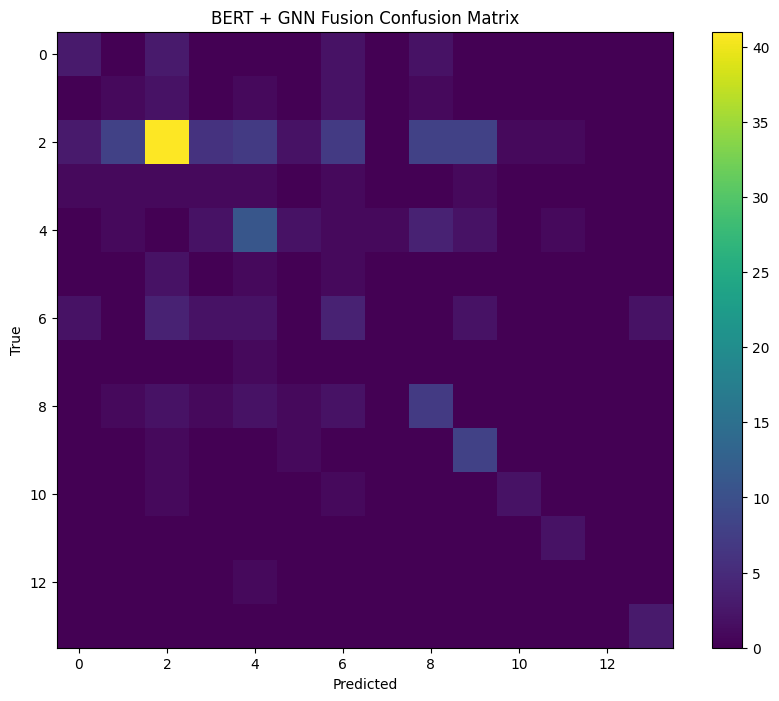

In [143]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


cm = confusion_matrix(
    true,
    preds
)


plt.figure(
    figsize=(10,8)
)

plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title(
    "BERT + GNN Fusion Confusion Matrix"
)

plt.colorbar()

plt.show()

In [144]:
MODEL_PATH = "/content/drive/MyDrive/gnn_bert_music_project/models/fusion_bert_gnn.pt"


torch.save(
    fusion_model.state_dict(),
    MODEL_PATH
)


print("Saved:", MODEL_PATH)

Saved: /content/drive/MyDrive/gnn_bert_music_project/models/fusion_bert_gnn.pt


In [145]:
results = {
    "GraphSAGE Accuracy":0.35,
    "GraphSAGE Macro F1":0.3658,

    "BERT_GNN Accuracy":0.415,
    "BERT_GNN Macro F1":0.327
}


results

{'GraphSAGE Accuracy': 0.35,
 'GraphSAGE Macro F1': 0.3658,
 'BERT_GNN Accuracy': 0.415,
 'BERT_GNN Macro F1': 0.327}